环境数据可视化分析
加载数据...
原始数据: (2124, 22)
SO2: IQR范围 [-22.000, 122.000]
NO2: IQR范围 [-19.500, 176.500]
PM10: IQR范围 [0.000, 304.000]
CO: IQR范围 [-30.375, 160.625]
O31小时: IQR范围 [-10.000, 62.000]
O38小时: IQR范围 [-13.000, 75.000]
PM2.5: IQR范围 [-71.875, 373.125]
移除离群值后: (1766, 22)
最终数据: (1766, 27)

数据统计摘要
总记录数: 1,766
时间范围: 2013-01-01 00:00:00 至 2013-04-26 00:00:00

污染物浓度统计:
  SO2: 均值=50.48, 中位数=48.00, 标准差=25.62
  NO2: 均值=78.27, 中位数=81.00, 标准差=29.97
  PM10: 均值=146.23, 中位数=143.00, 标准差=51.53
  CO: 均值=65.17, 中位数=65.00, 标准差=27.59
  PM2.5: 均值=156.35, 中位数=140.00, 标准差=77.35
  O31小时: 均值=25.74, 中位数=26.00, 标准差=11.62
  O38小时: 均值=31.15, 中位数=31.00, 标准差=14.79

天气类别分布:
  晴: 848 (48.0%)
  多云: 592 (33.5%)
  阴: 212 (12.0%)
  雨: 94 (5.3%)
  雪: 20 (1.1%)

污染程度统计:
  平均污染程度: 3.90
  污染程度范围: 0.0 - 7.0

气象条件统计:
  气温范围: -7.0°C - 33.0°C
  平均气温: 11.4°C
  降水强度范围: 0.0 - 2.0

生成数据概览可视化...


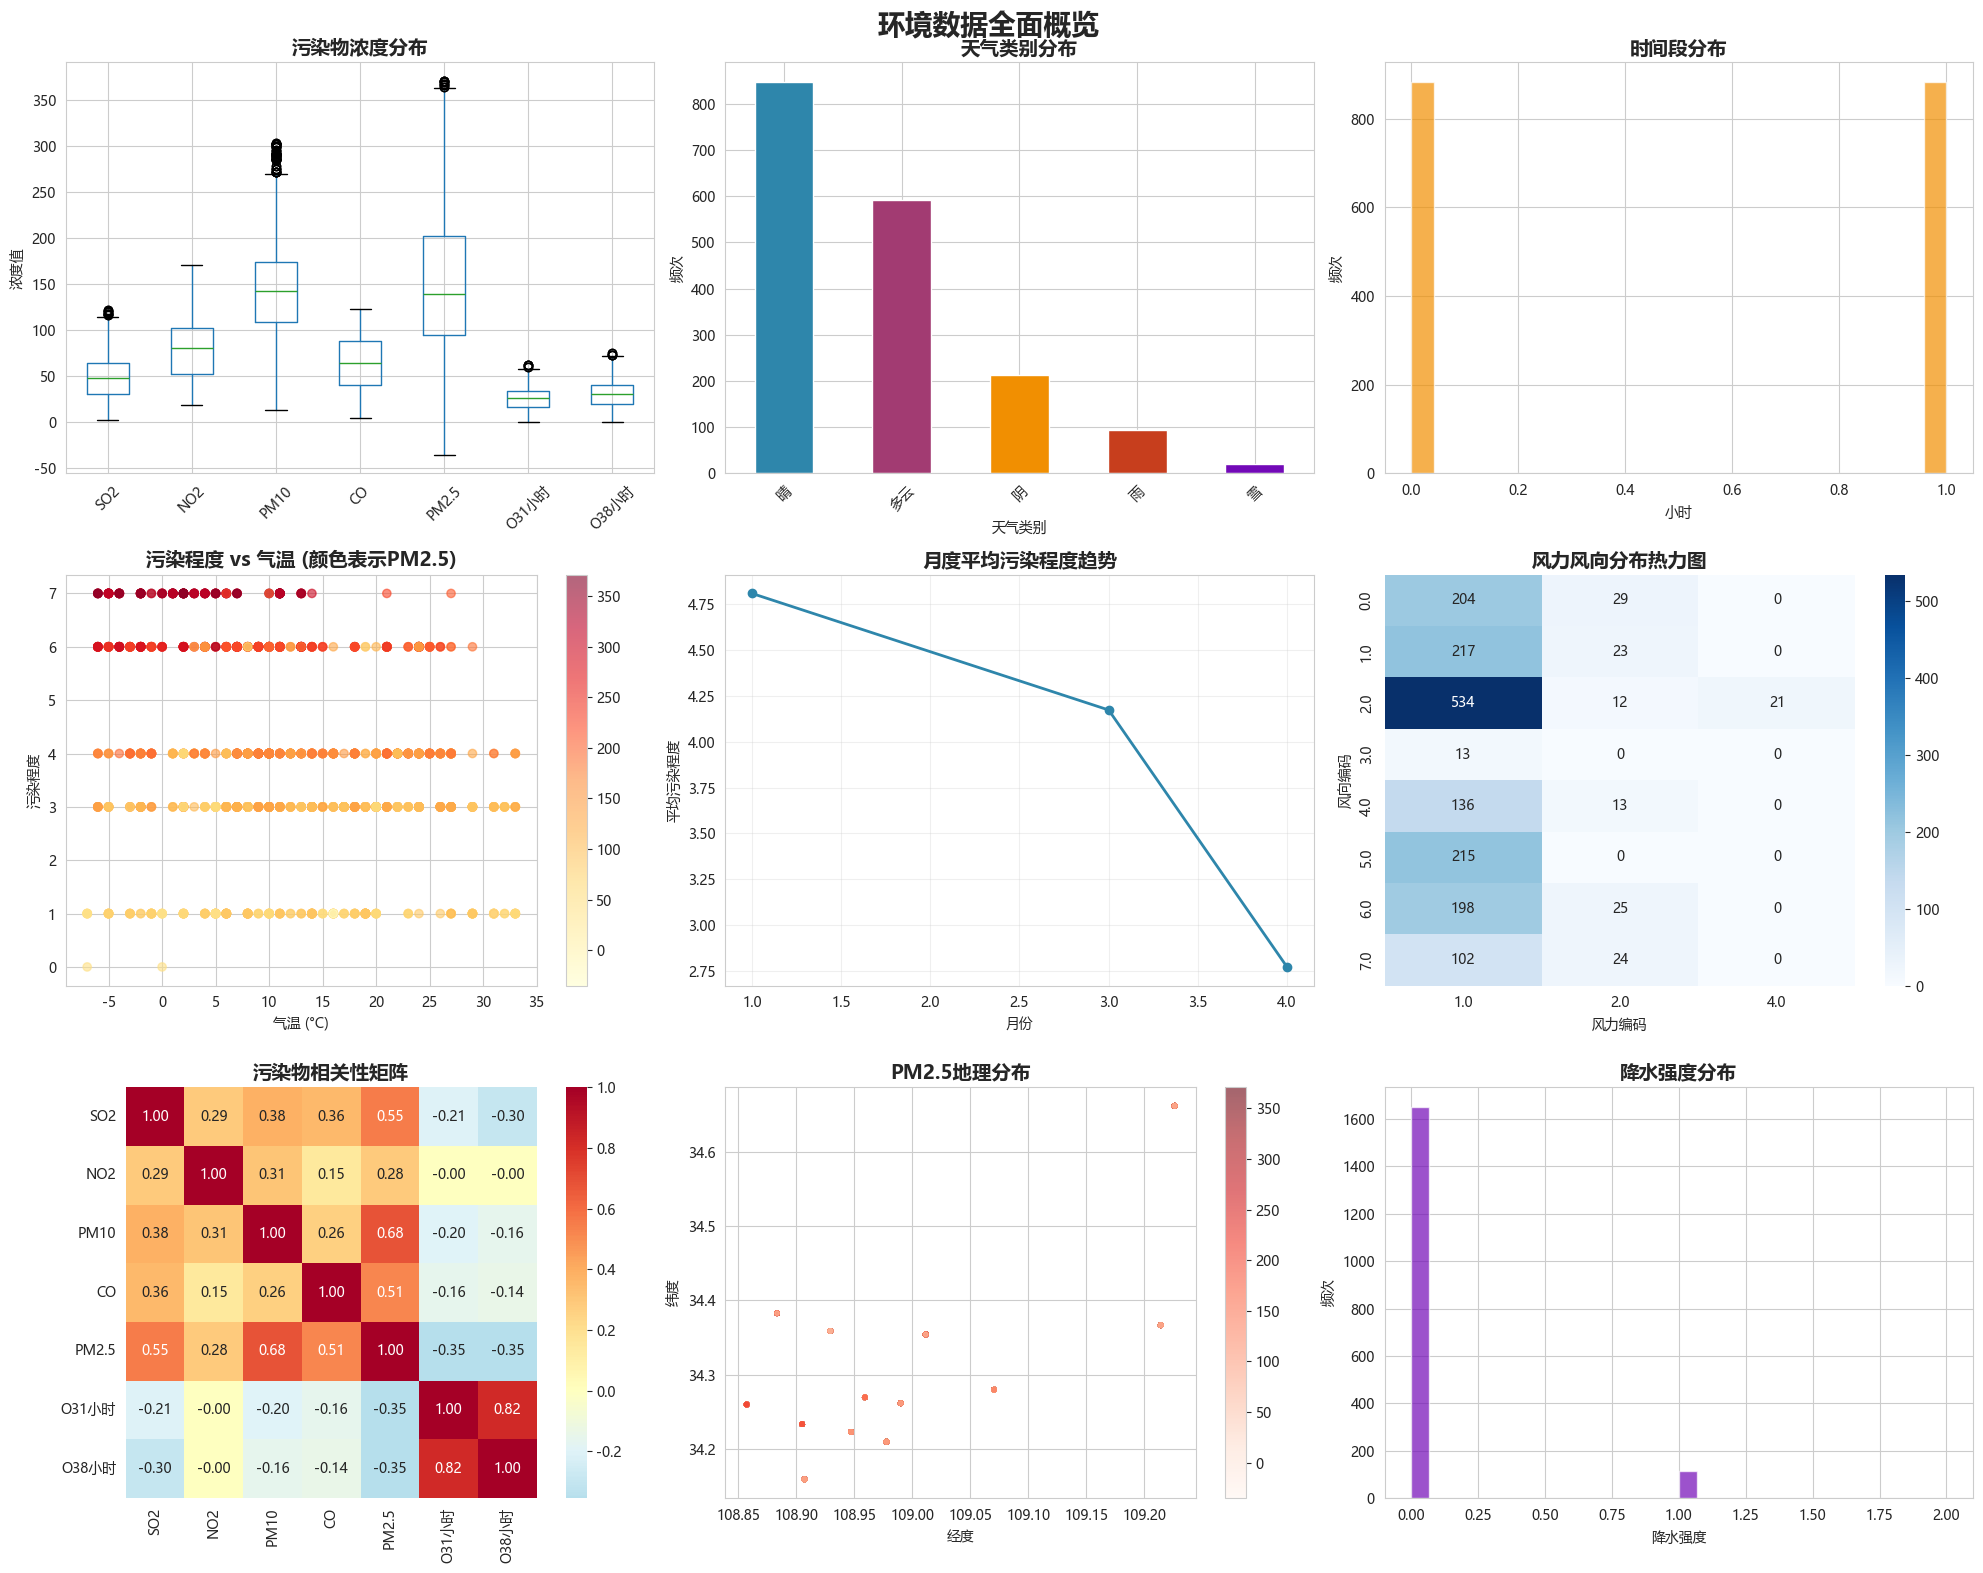

生成特征关系可视化...


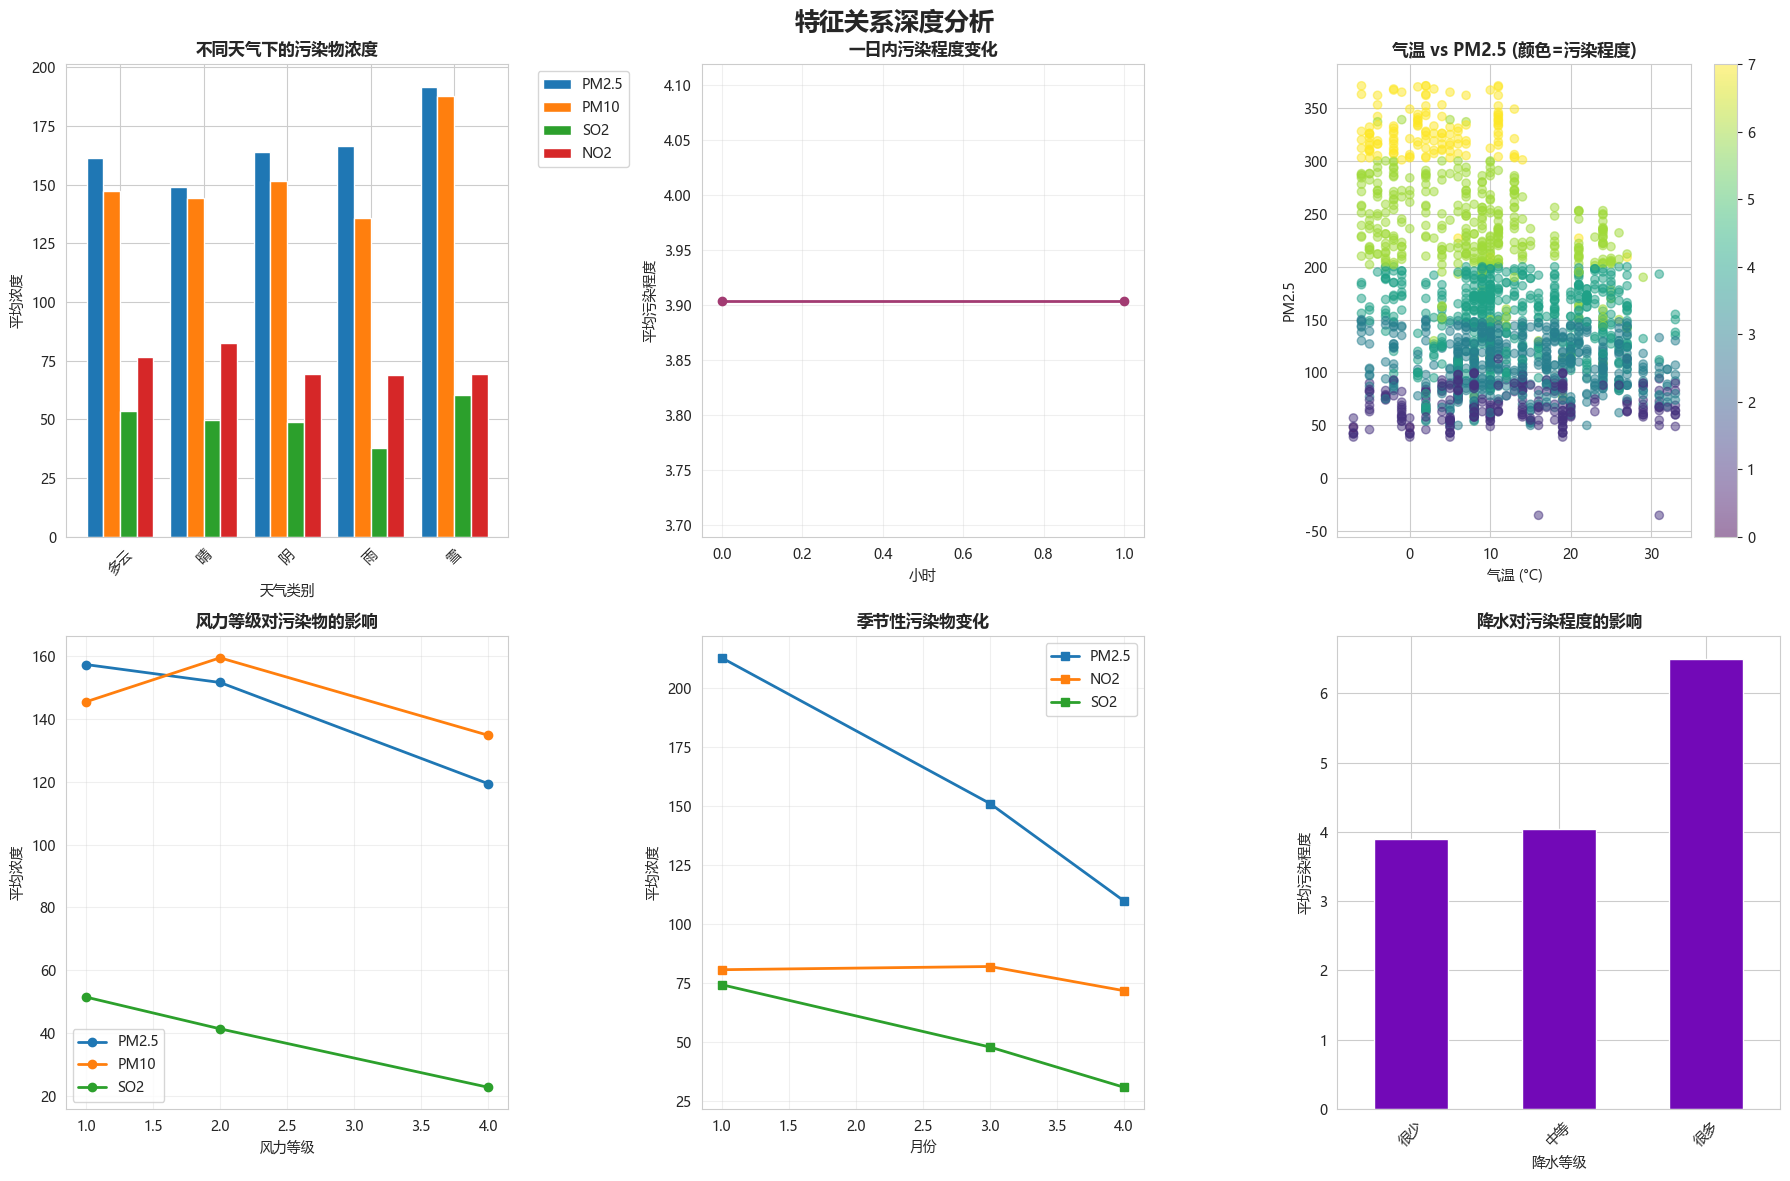


可视化完成！
生成的文件:
- data_overview.png: 数据概览
- feature_relationships.png: 特征关系分析


In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams

# 尝试多种中文字体方案
try:
    # 方案1：使用系统默认中文字体
    rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'Songti SC', 'STHeiti']
    rcParams['axes.unicode_minus'] = False
    
    # 验证字体是否可用
    if not any('hei' in f.lower() or 'yahei' in f.lower() for f in fm.get_font_names()):
        # 方案2：如果默认字体不可用，尝试加载特定字体文件
        try:
            font_path = 'C:/Windows/Fonts/simhei.ttf'  # Windows常见路径
            font_prop = fm.FontProperties(fname=font_path)
            rcParams['font.family'] = font_prop.get_name()
        except:
            # 方案3：使用系统可用的任何中文字体
            chinese_fonts = [f for f in fm.fontManager.ttflist if any('han' in f.name.lower() or 'hei' in f.name.lower() or 'song' in f.name.lower() for f in fm.fontManager.ttflist)]
            if chinese_fonts:
                rcParams['font.family'] = chinese_fonts[0].name
except Exception as e:
    print(f"字体设置错误: {e}")
class EnvironmentalDataVisualizer:
    """环境数据可视化分析器"""
    
    def __init__(self):
        # 可视化配置
        self.colors = {
            'primary': '#2E86AB',
            'secondary': '#A23B72',
            'accent': '#F18F01',
            'success': '#C73E1D',
            'info': '#7209B7',
            'warning': '#F4A261',
            'danger': '#E63946'
        }

    def load_and_preprocess_data(self, file_path):
        """加载和预处理数据"""
        columns = ['纬度', '经度', 'SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5', 
                  '污染程度', '日期', '时间段', '气温', '风向编码', '风力编码', '降水强度', 
                  '天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        
        data = pd.read_csv(file_path, usecols=columns)
        print(f"原始数据: {data.shape}")
        
        # 清理异常值
        numeric_cols = ['SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5']
        for col in numeric_cols:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            print(f"{col}: IQR范围 [{lower_bound:.3f}, {upper_bound:.3f}]")
            data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
        
        print(f"移除离群值后: {data.shape}")
        
        # 强制转换数值类型并处理无效值
        numeric_columns = ['纬度', '经度', 'SO2', 'NO2', 'PM10', 'CO', 'O31小时', 'O38小时', 'PM2.5', 
                          '污染程度', '时间段', '气温', '风向编码', '风力编码', '降水强度', 
                          '天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        
        for col in numeric_columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')
            if data[col].isna().sum() > 0:
                median_val = data[col].median()
                data[col].fillna(median_val, inplace=True)
                print(f"{col}: 用中位数 {median_val:.3f} 填充了 {data[col].isna().sum()} 个NaN值")
        
        # 日期处理
        data['日期'] = pd.to_datetime(data['日期'])
        data['年'] = data['日期'].dt.year
        data['月'] = data['日期'].dt.month
        data['日'] = data['日期'].dt.day
        data['星期'] = data['日期'].dt.dayofweek
        
        # 天气标签处理
        weather_cols = ['天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        data['天气类别'] = data[weather_cols].idxmax(axis=1).str.replace('天气_', '')
        
        # 最终数据清理
        data = data.replace([np.inf, -np.inf], np.nan)
        data = data.dropna()
        
        print(f"最终数据: {data.shape}")
        return data

    def visualize_data_overview(self, data, save_path='data_overview.png'):
        """数据概览可视化"""
        fig, axes = plt.subplots(3, 3, figsize=(20, 16))
        fig.suptitle('环境数据全面概览', fontsize=20, fontweight='bold')
        
        # 1. 污染物分布
        pollutant_cols = ['SO2', 'NO2', 'PM10', 'CO', 'PM2.5', 'O31小时', 'O38小时']
        ax = axes[0, 0]
        data[pollutant_cols].boxplot(ax=ax)
        ax.set_title('污染物浓度分布', fontsize=14, fontweight='bold')
        ax.set_ylabel('浓度值')
        ax.tick_params(axis='x', rotation=45)
        
        # 2. 天气类别分布
        ax = axes[0, 1]
        weather_counts = data['天气类别'].value_counts()
        colors = [self.colors['primary'], self.colors['secondary'], self.colors['accent'], 
                 self.colors['success'], self.colors['info'], self.colors['warning']]
        weather_counts.plot(kind='bar', ax=ax, color=colors[:len(weather_counts)])
        ax.set_title('天气类别分布', fontsize=14, fontweight='bold')
        ax.set_ylabel('频次')
        ax.tick_params(axis='x', rotation=45)
        
        # 3. 时间分布
        ax = axes[0, 2]
        data['时间段'].hist(bins=24, ax=ax, color=self.colors['accent'], alpha=0.7)
        ax.set_title('时间段分布', fontsize=14, fontweight='bold')
        ax.set_xlabel('小时')
        ax.set_ylabel('频次')
        
        # 4. 污染程度与气温关系
        ax = axes[1, 0]
        scatter = ax.scatter(data['气温'], data['污染程度'], 
                           c=data['PM2.5'], cmap='YlOrRd', alpha=0.6)
        ax.set_title('污染程度 vs 气温 (颜色表示PM2.5)', fontsize=14, fontweight='bold')
        ax.set_xlabel('气温 (°C)')
        ax.set_ylabel('污染程度')
        plt.colorbar(scatter, ax=ax)
        
        # 5. 月度趋势
        ax = axes[1, 1]
        monthly_pollution = data.groupby('月')['污染程度'].mean()
        monthly_pollution.plot(kind='line', ax=ax, marker='o', 
                              color=self.colors['primary'], linewidth=2, markersize=6)
        ax.set_title('月度平均污染程度趋势', fontsize=14, fontweight='bold')
        ax.set_xlabel('月份')
        ax.set_ylabel('平均污染程度')
        ax.grid(True, alpha=0.3)
        
        # 6. 风力风向分布
        ax = axes[1, 2]
        wind_data = data.groupby(['风向编码', '风力编码']).size().unstack(fill_value=0)
        sns.heatmap(wind_data, ax=ax, cmap='Blues', annot=True, fmt='d')
        ax.set_title('风力风向分布热力图', fontsize=14, fontweight='bold')
        ax.set_xlabel('风力编码')
        ax.set_ylabel('风向编码')
        
        # 7. 污染物相关性
        ax = axes[2, 0]
        pollutant_corr = data[pollutant_cols].corr()
        sns.heatmap(pollutant_corr, ax=ax, annot=True, cmap='RdYlBu_r', 
                   center=0, square=True, fmt='.2f')
        ax.set_title('污染物相关性矩阵', fontsize=14, fontweight='bold')
        
        # 8. 地理分布
        ax = axes[2, 1]
        scatter = ax.scatter(data['经度'], data['纬度'], 
                           c=data['PM2.5'], cmap='Reds', alpha=0.6, s=10)
        ax.set_title('PM2.5地理分布', fontsize=14, fontweight='bold')
        ax.set_xlabel('经度')
        ax.set_ylabel('纬度')
        plt.colorbar(scatter, ax=ax)
        
        # 9. 降水强度分布
        ax = axes[2, 2]
        data['降水强度'].hist(bins=30, ax=ax, color=self.colors['info'], alpha=0.7)
        ax.set_title('降水强度分布', fontsize=14, fontweight='bold')
        ax.set_xlabel('降水强度')
        ax.set_ylabel('频次')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def visualize_feature_relationships(self, data, save_path='feature_relationships.png'):
        """特征关系可视化"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('特征关系深度分析', fontsize=18, fontweight='bold')
        
        # 1. 污染物vs天气类别
        ax = axes[0, 0]
        weather_pollution = data.groupby('天气类别')[['PM2.5', 'PM10', 'SO2', 'NO2']].mean()
        weather_pollution.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title('不同天气下的污染物浓度', fontsize=12, fontweight='bold')
        ax.set_ylabel('平均浓度')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # 2. 时间vs污染程度
        ax = axes[0, 1]
        hour_pollution = data.groupby('时间段')['污染程度'].mean()
        hour_pollution.plot(ax=ax, color=self.colors['secondary'], linewidth=2, marker='o')
        ax.set_title('一日内污染程度变化', fontsize=12, fontweight='bold')
        ax.set_xlabel('小时')
        ax.set_ylabel('平均污染程度')
        ax.grid(True, alpha=0.3)
        
        # 3. 气温vs污染物散点图矩阵
        ax = axes[0, 2]
        temp_pm25 = ax.scatter(data['气温'], data['PM2.5'], alpha=0.5, 
                              c=data['污染程度'], cmap='viridis')
        ax.set_title('气温 vs PM2.5 (颜色=污染程度)', fontsize=12, fontweight='bold')
        ax.set_xlabel('气温 (°C)')
        ax.set_ylabel('PM2.5')
        plt.colorbar(temp_pm25, ax=ax)
        
        # 4. 风力对污染的影响
        ax = axes[1, 0]
        wind_pollution = data.groupby('风力编码')[['PM2.5', 'PM10', 'SO2']].mean()
        wind_pollution.plot(ax=ax, marker='o', linewidth=2)
        ax.set_title('风力等级对污染物的影响', fontsize=12, fontweight='bold')
        ax.set_xlabel('风力等级')
        ax.set_ylabel('平均浓度')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # 5. 季节性分析
        ax = axes[1, 1]
        seasonal_data = data.groupby('月')[['PM2.5', 'NO2', 'SO2']].mean()
        seasonal_data.plot(ax=ax, marker='s', linewidth=2)
        ax.set_title('季节性污染物变化', fontsize=12, fontweight='bold')
        ax.set_xlabel('月份')
        ax.set_ylabel('平均浓度')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # 6. 降水vs污染关系
        ax = axes[1, 2]
        # 将降水强度分组
        data['降水等级'] = pd.cut(data['降水强度'], bins=5, labels=['很少', '少', '中等', '多', '很多'])
        rain_pollution = data.groupby('降水等级')['污染程度'].mean().dropna()
        rain_pollution.plot(kind='bar', ax=ax, color=self.colors['info'])
        ax.set_title('降水对污染程度的影响', fontsize=12, fontweight='bold')
        ax.set_ylabel('平均污染程度')
        ax.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def generate_data_summary(self, data):
        """生成数据统计摘要"""
        print("\n" + "="*60)
        print("数据统计摘要")
        print("="*60)
        
        print(f"总记录数: {len(data):,}")
        print(f"时间范围: {data['日期'].min()} 至 {data['日期'].max()}")
        
        print("\n污染物浓度统计:")
        pollutant_cols = ['SO2', 'NO2', 'PM10', 'CO', 'PM2.5', 'O31小时', 'O38小时']
        for col in pollutant_cols:
            print(f"  {col}: 均值={data[col].mean():.2f}, 中位数={data[col].median():.2f}, "
                  f"标准差={data[col].std():.2f}")
        
        print(f"\n天气类别分布:")
        weather_counts = data['天气类别'].value_counts()
        for weather, count in weather_counts.items():
            percentage = count / len(data) * 100
            print(f"  {weather}: {count:,} ({percentage:.1f}%)")
        
        print(f"\n污染程度统计:")
        print(f"  平均污染程度: {data['污染程度'].mean():.2f}")
        print(f"  污染程度范围: {data['污染程度'].min():.1f} - {data['污染程度'].max():.1f}")
        
        print(f"\n气象条件统计:")
        print(f"  气温范围: {data['气温'].min():.1f}°C - {data['气温'].max():.1f}°C")
        print(f"  平均气温: {data['气温'].mean():.1f}°C")
        print(f"  降水强度范围: {data['降水强度'].min():.1f} - {data['降水强度'].max():.1f}")

def main():
    """主函数 - 仅生成可视化"""
    print("=" * 60)
    print("环境数据可视化分析")
    print("=" * 60)
    
    visualizer = EnvironmentalDataVisualizer()
    
    # 加载数据
    print("加载数据...")
    try:
        data = visualizer.load_and_preprocess_data('end_cleaned.csv')
    except FileNotFoundError:
        print("数据文件未找到，请确保 'end_cleaned.csv' 在当前目录")
        return
    
    # 生成数据统计摘要
    visualizer.generate_data_summary(data)
    
    # 数据可视化
    print("\n生成数据概览可视化...")
    visualizer.visualize_data_overview(data)
    
    print("生成特征关系可视化...")
    visualizer.visualize_feature_relationships(data)
    
    print("\n可视化完成！")
    print("生成的文件:")
    print("- data_overview.png: 数据概览")
    print("- feature_relationships.png: 特征关系分析")

if __name__ == "__main__":
    main()

环境数据可视化分析
加载数据...
原始数据: (20198, 18)
SO2: IQR范围 [-29.000, 99.000]
NO2: IQR范围 [-10.000, 62.000]
PM10: IQR范围 [14.000, 142.000]
移除离群值后: (17184, 18)
最终数据: (17184, 23)

数据统计摘要
总记录数: 17,184
时间范围: 2011-01-02 00:00:00 至 2013-04-26 00:00:00

污染物浓度统计:
  SO2: 均值=31.31, 中位数=25.00, 标准差=18.56
  NO2: 均值=24.22, 中位数=22.00, 标准差=10.55
  PM10: 均值=77.85, 中位数=77.00, 标准差=21.92

天气类别分布:
  多云: 6,124 (35.6%)
  晴: 4,065 (23.7%)
  阴: 3,673 (21.4%)
  雨: 3,079 (17.9%)
  雪: 233 (1.4%)
  雾霾沙尘: 10 (0.1%)

污染程度统计:
  平均污染程度: 1.06
  污染程度范围: 0.0 - 6.0

气象条件统计:
  气温范围: -7.0°C - 38.0°C
  平均气温: 16.0°C
  降水强度范围: 0.0 - 4.0

生成数据概览可视化...


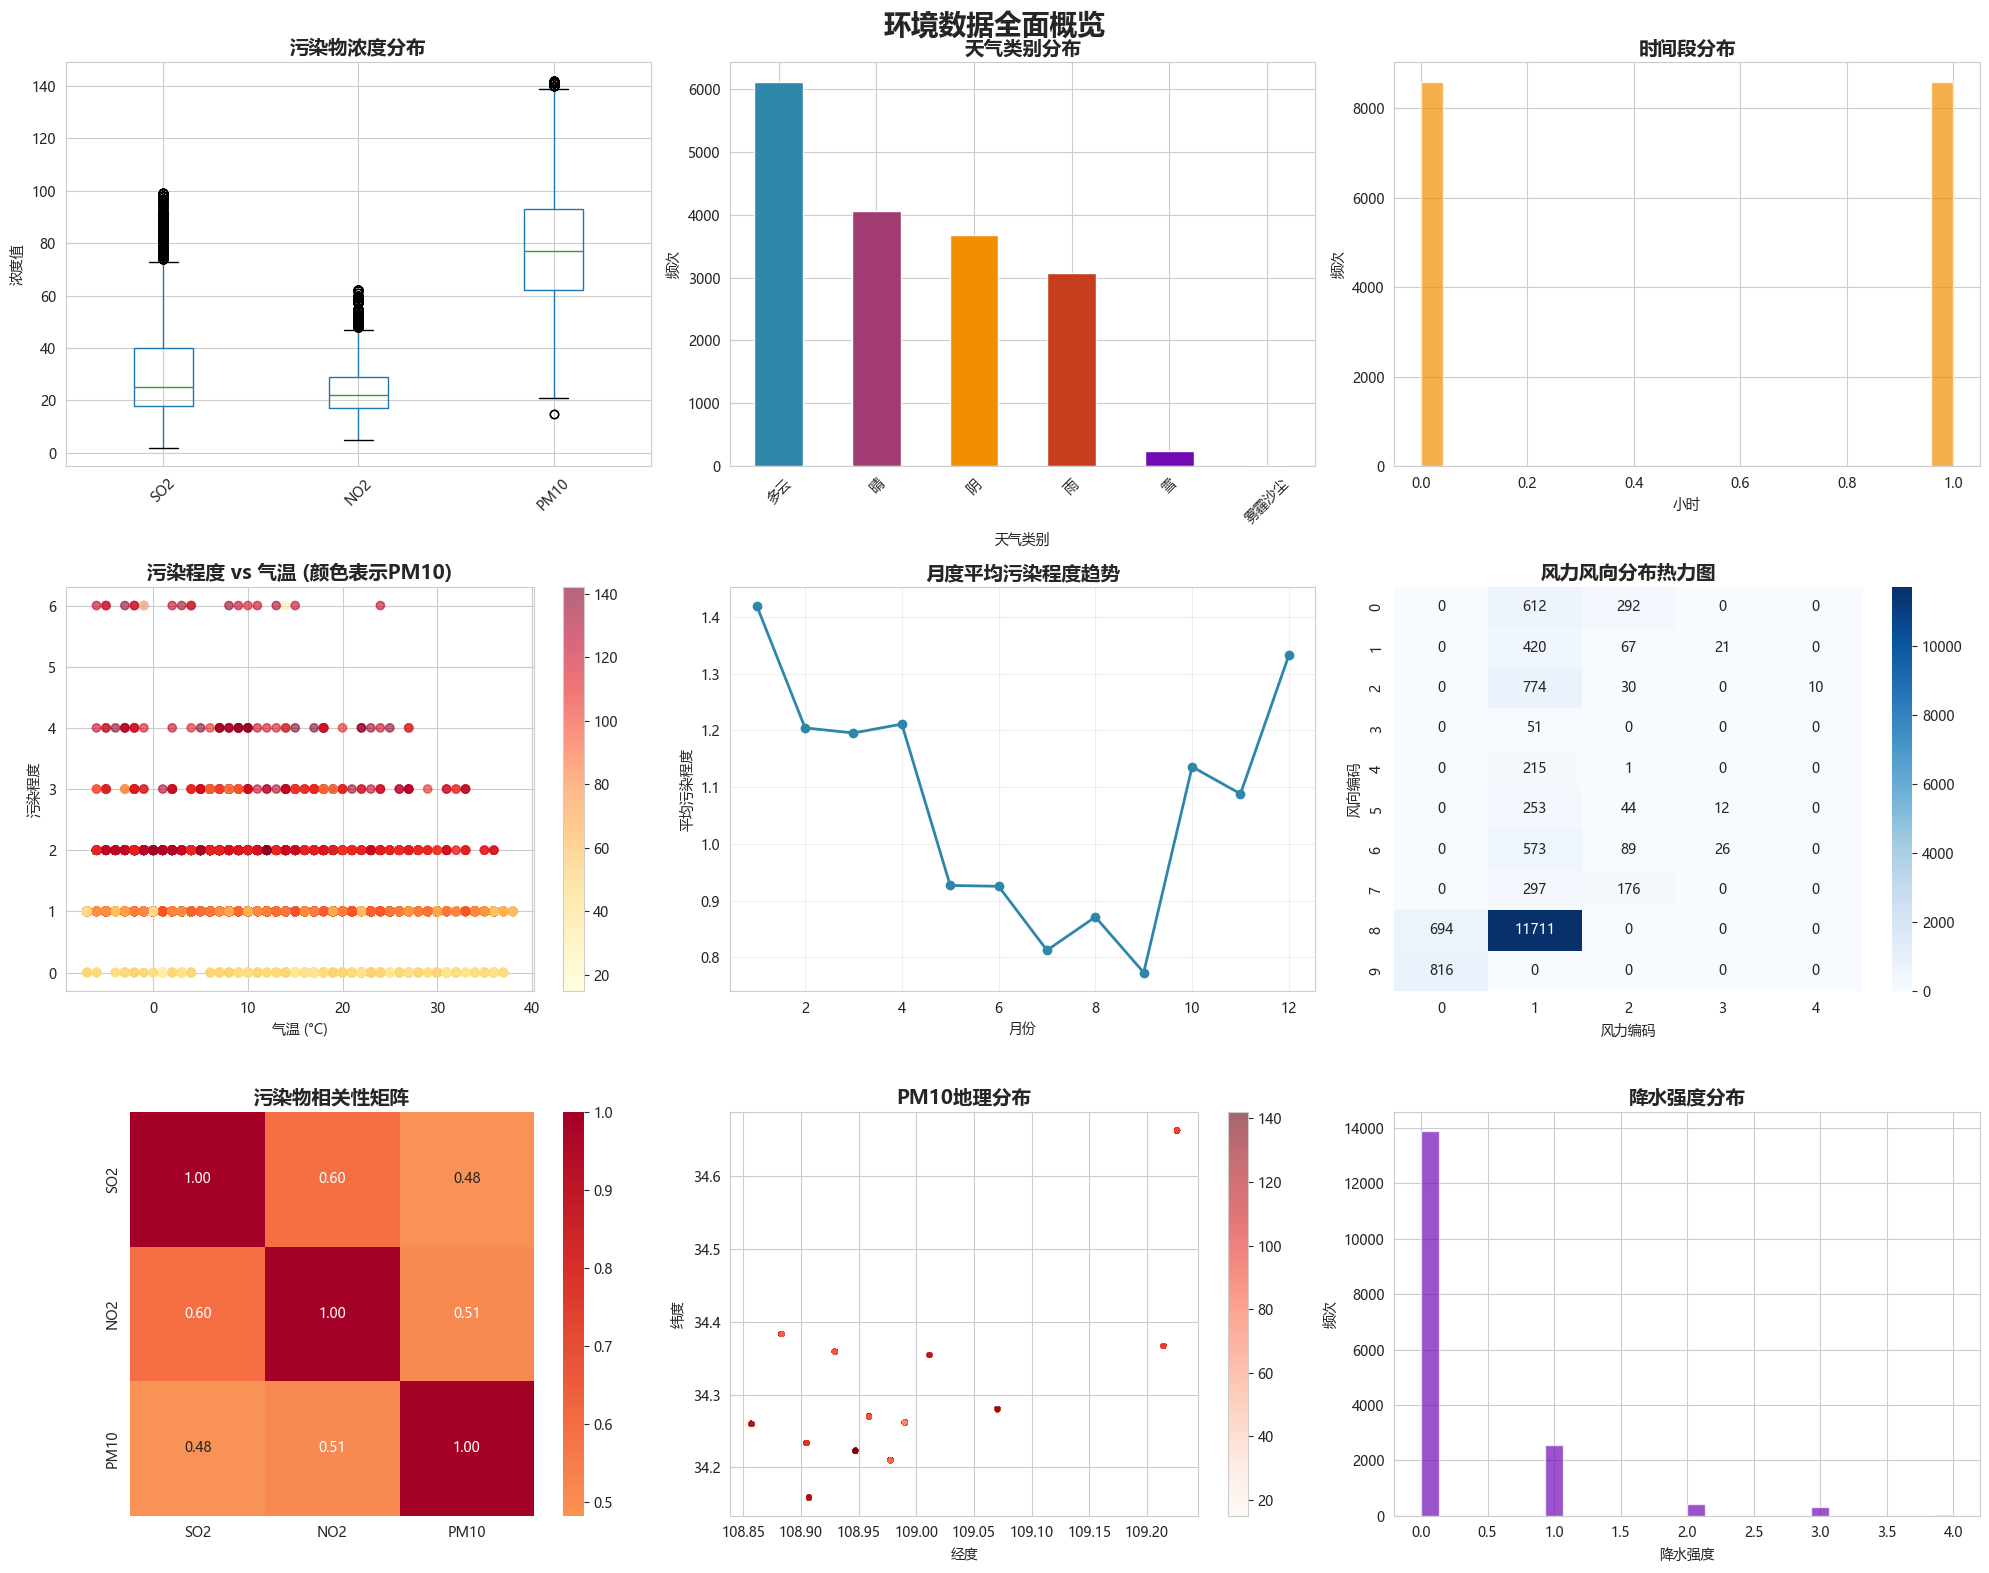

生成特征关系可视化...


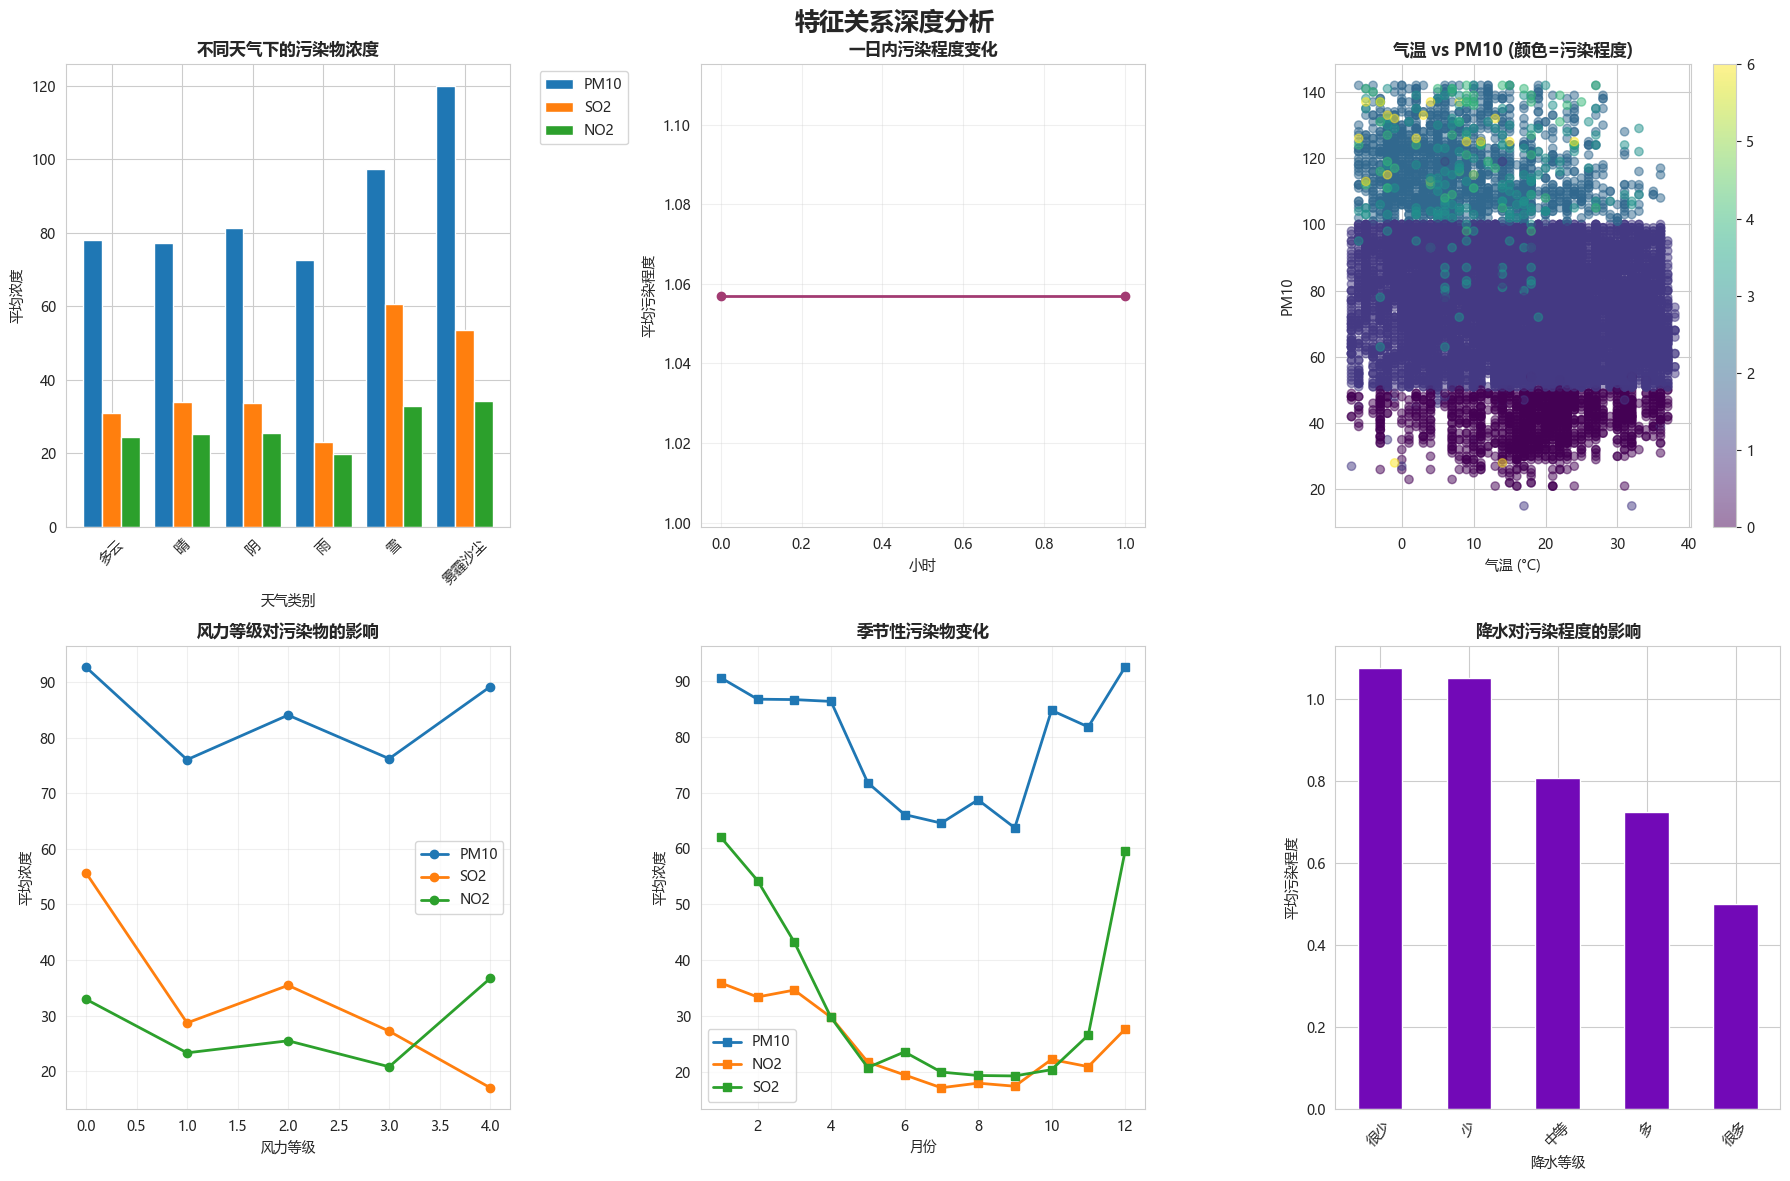


可视化完成！
生成的文件:
- data_overview.png: 数据概览
- feature_relationships.png: 特征关系分析


In [11]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
import pandas as pd
import numpy as np
import seaborn as sns

# 尝试多种中文字体方案
try:
    # 方案1：使用系统默认中文字体
    rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'Songti SC', 'STHeiti']
    rcParams['axes.unicode_minus'] = False
    
    # 验证字体是否可用
    if not any('hei' in f.lower() or 'yahei' in f.lower() for f in fm.get_font_names()):
        # 方案2：如果默认字体不可用，尝试加载特定字体文件
        try:
            font_path = 'C:/Windows/Fonts/simhei.ttf'  # Windows常见路径
            font_prop = fm.FontProperties(fname=font_path)
            rcParams['font.family'] = font_prop.get_name()
        except:
            # 方案3：使用系统可用的任何中文字体
            chinese_fonts = [f for f in fm.fontManager.ttflist if any('han' in f.name.lower() or 'hei' in f.name.lower() or 'song' in f.name.lower() for f in fm.fontManager.ttflist)]
            if chinese_fonts:
                rcParams['font.family'] = chinese_fonts[0].name
except Exception as e:
    print(f"字体设置错误: {e}")

class EnvironmentalDataVisualizer:
    """环境数据可视化分析器"""
    
    def __init__(self):
        # 可视化配置
        self.colors = {
            'primary': '#2E86AB',
            'secondary': '#A23B72',
            'accent': '#F18F01',
            'success': '#C73E1D',
            'info': '#7209B7',
            'warning': '#F4A261',
            'danger': '#E63946'
        }

    def load_and_preprocess_data(self, file_path):
        """加载和预处理数据"""
        # 修改：只包含三个污染物
        columns = ['纬度', '经度', 'SO2', 'NO2', 'PM10', 
                  '污染程度', '日期', '时间段', '气温', '风向编码', '风力编码', '降水强度', 
                  '天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        
        data = pd.read_csv(file_path, usecols=columns)
        print(f"原始数据: {data.shape}")
        
        # 清理异常值 - 修改：只处理三个污染物
        numeric_cols = ['SO2', 'NO2', 'PM10']
        for col in numeric_cols:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            print(f"{col}: IQR范围 [{lower_bound:.3f}, {upper_bound:.3f}]")
            data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
        
        print(f"移除离群值后: {data.shape}")
        
        # 强制转换数值类型并处理无效值 - 修改：移除不存在的污染物列
        numeric_columns = ['纬度', '经度', 'SO2', 'NO2', 'PM10', 
                          '污染程度', '时间段', '气温', '风向编码', '风力编码', '降水强度', 
                          '天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        
        for col in numeric_columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')
            if data[col].isna().sum() > 0:
                median_val = data[col].median()
                data[col].fillna(median_val, inplace=True)
                print(f"{col}: 用中位数 {median_val:.3f} 填充了 {data[col].isna().sum()} 个NaN值")
        
        # 日期处理
        data['日期'] = pd.to_datetime(data['日期'])
        data['年'] = data['日期'].dt.year
        data['月'] = data['日期'].dt.month
        data['日'] = data['日期'].dt.day
        data['星期'] = data['日期'].dt.dayofweek
        
        # 天气标签处理
        weather_cols = ['天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        data['天气类别'] = data[weather_cols].idxmax(axis=1).str.replace('天气_', '')
        
        # 最终数据清理
        data = data.replace([np.inf, -np.inf], np.nan)
        data = data.dropna()
        
        print(f"最终数据: {data.shape}")
        return data

    def visualize_data_overview(self, data, save_path='data_overview.png'):
        """数据概览可视化"""
        fig, axes = plt.subplots(3, 3, figsize=(20, 16))
        fig.suptitle('环境数据全面概览', fontsize=20, fontweight='bold')
        
        # 1. 污染物分布 - 修改：只包含三个污染物
        pollutant_cols = ['SO2', 'NO2', 'PM10']
        ax = axes[0, 0]
        data[pollutant_cols].boxplot(ax=ax)
        ax.set_title('污染物浓度分布', fontsize=14, fontweight='bold')
        ax.set_ylabel('浓度值')
        ax.tick_params(axis='x', rotation=45)
        
        # 2. 天气类别分布
        ax = axes[0, 1]
        weather_counts = data['天气类别'].value_counts()
        colors = [self.colors['primary'], self.colors['secondary'], self.colors['accent'], 
                 self.colors['success'], self.colors['info'], self.colors['warning']]
        weather_counts.plot(kind='bar', ax=ax, color=colors[:len(weather_counts)])
        ax.set_title('天气类别分布', fontsize=14, fontweight='bold')
        ax.set_ylabel('频次')
        ax.tick_params(axis='x', rotation=45)
        
        # 3. 时间分布
        ax = axes[0, 2]
        data['时间段'].hist(bins=24, ax=ax, color=self.colors['accent'], alpha=0.7)
        ax.set_title('时间段分布', fontsize=14, fontweight='bold')
        ax.set_xlabel('小时')
        ax.set_ylabel('频次')
        
        # 4. 污染程度与气温关系 - 修改：使用PM10作为颜色映射
        ax = axes[1, 0]
        scatter = ax.scatter(data['气温'], data['污染程度'], 
                           c=data['PM10'], cmap='YlOrRd', alpha=0.6)
        ax.set_title('污染程度 vs 气温 (颜色表示PM10)', fontsize=14, fontweight='bold')
        ax.set_xlabel('气温 (°C)')
        ax.set_ylabel('污染程度')
        plt.colorbar(scatter, ax=ax)
        
        # 5. 月度趋势
        ax = axes[1, 1]
        monthly_pollution = data.groupby('月')['污染程度'].mean()
        monthly_pollution.plot(kind='line', ax=ax, marker='o', 
                              color=self.colors['primary'], linewidth=2, markersize=6)
        ax.set_title('月度平均污染程度趋势', fontsize=14, fontweight='bold')
        ax.set_xlabel('月份')
        ax.set_ylabel('平均污染程度')
        ax.grid(True, alpha=0.3)
        
        # 6. 风力风向分布
        ax = axes[1, 2]
        wind_data = data.groupby(['风向编码', '风力编码']).size().unstack(fill_value=0)
        sns.heatmap(wind_data, ax=ax, cmap='Blues', annot=True, fmt='d')
        ax.set_title('风力风向分布热力图', fontsize=14, fontweight='bold')
        ax.set_xlabel('风力编码')
        ax.set_ylabel('风向编码')
        
        # 7. 污染物相关性 - 修改：只包含三个污染物
        ax = axes[2, 0]
        pollutant_corr = data[pollutant_cols].corr()
        sns.heatmap(pollutant_corr, ax=ax, annot=True, cmap='RdYlBu_r', 
                   center=0, square=True, fmt='.2f')
        ax.set_title('污染物相关性矩阵', fontsize=14, fontweight='bold')
        
        # 8. 地理分布 - 修改：使用PM10作为颜色映射
        ax = axes[2, 1]
        scatter = ax.scatter(data['经度'], data['纬度'], 
                           c=data['PM10'], cmap='Reds', alpha=0.6, s=10)
        ax.set_title('PM10地理分布', fontsize=14, fontweight='bold')
        ax.set_xlabel('经度')
        ax.set_ylabel('纬度')
        plt.colorbar(scatter, ax=ax)
        
        # 9. 降水强度分布
        ax = axes[2, 2]
        data['降水强度'].hist(bins=30, ax=ax, color=self.colors['info'], alpha=0.7)
        ax.set_title('降水强度分布', fontsize=14, fontweight='bold')
        ax.set_xlabel('降水强度')
        ax.set_ylabel('频次')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def visualize_feature_relationships(self, data, save_path='feature_relationships.png'):
        """特征关系可视化"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('特征关系深度分析', fontsize=18, fontweight='bold')
        
        # 1. 污染物vs天气类别 - 修改：只包含三个污染物
        ax = axes[0, 0]
        weather_pollution = data.groupby('天气类别')[['PM10', 'SO2', 'NO2']].mean()
        weather_pollution.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title('不同天气下的污染物浓度', fontsize=12, fontweight='bold')
        ax.set_ylabel('平均浓度')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # 2. 时间vs污染程度
        ax = axes[0, 1]
        hour_pollution = data.groupby('时间段')['污染程度'].mean()
        hour_pollution.plot(ax=ax, color=self.colors['secondary'], linewidth=2, marker='o')
        ax.set_title('一日内污染程度变化', fontsize=12, fontweight='bold')
        ax.set_xlabel('小时')
        ax.set_ylabel('平均污染程度')
        ax.grid(True, alpha=0.3)
        
        # 3. 气温vs污染物散点图矩阵 - 修改：使用PM10替代PM2.5
        ax = axes[0, 2]
        temp_pm10 = ax.scatter(data['气温'], data['PM10'], alpha=0.5, 
                              c=data['污染程度'], cmap='viridis')
        ax.set_title('气温 vs PM10 (颜色=污染程度)', fontsize=12, fontweight='bold')
        ax.set_xlabel('气温 (°C)')
        ax.set_ylabel('PM10')
        plt.colorbar(temp_pm10, ax=ax)
        
        # 4. 风力对污染的影响 - 修改：只包含三个污染物
        ax = axes[1, 0]
        wind_pollution = data.groupby('风力编码')[['PM10', 'SO2', 'NO2']].mean()
        wind_pollution.plot(ax=ax, marker='o', linewidth=2)
        ax.set_title('风力等级对污染物的影响', fontsize=12, fontweight='bold')
        ax.set_xlabel('风力等级')
        ax.set_ylabel('平均浓度')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # 5. 季节性分析 - 修改：只包含三个污染物
        ax = axes[1, 1]
        seasonal_data = data.groupby('月')[['PM10', 'NO2', 'SO2']].mean()
        seasonal_data.plot(ax=ax, marker='s', linewidth=2)
        ax.set_title('季节性污染物变化', fontsize=12, fontweight='bold')
        ax.set_xlabel('月份')
        ax.set_ylabel('平均浓度')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # 6. 降水vs污染关系
        ax = axes[1, 2]
        # 将降水强度分组
        data['降水等级'] = pd.cut(data['降水强度'], bins=5, labels=['很少', '少', '中等', '多', '很多'])
        rain_pollution = data.groupby('降水等级')['污染程度'].mean().dropna()
        rain_pollution.plot(kind='bar', ax=ax, color=self.colors['info'])
        ax.set_title('降水对污染程度的影响', fontsize=12, fontweight='bold')
        ax.set_ylabel('平均污染程度')
        ax.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def generate_data_summary(self, data):
        """生成数据统计摘要"""
        print("\n" + "="*60)
        print("数据统计摘要")
        print("="*60)
        
        print(f"总记录数: {len(data):,}")
        print(f"时间范围: {data['日期'].min()} 至 {data['日期'].max()}")
        
        print("\n污染物浓度统计:")
        # 修改：只包含三个污染物
        pollutant_cols = ['SO2', 'NO2', 'PM10']
        for col in pollutant_cols:
            print(f"  {col}: 均值={data[col].mean():.2f}, 中位数={data[col].median():.2f}, "
                  f"标准差={data[col].std():.2f}")
        
        print(f"\n天气类别分布:")
        weather_counts = data['天气类别'].value_counts()
        for weather, count in weather_counts.items():
            percentage = count / len(data) * 100
            print(f"  {weather}: {count:,} ({percentage:.1f}%)")
        
        print(f"\n污染程度统计:")
        print(f"  平均污染程度: {data['污染程度'].mean():.2f}")
        print(f"  污染程度范围: {data['污染程度'].min():.1f} - {data['污染程度'].max():.1f}")
        
        print(f"\n气象条件统计:")
        print(f"  气温范围: {data['气温'].min():.1f}°C - {data['气温'].max():.1f}°C")
        print(f"  平均气温: {data['气温'].mean():.1f}°C")
        print(f"  降水强度范围: {data['降水强度'].min():.1f} - {data['降水强度'].max():.1f}")

def main():
    """主函数 - 仅生成可视化"""
    print("=" * 60)
    print("环境数据可视化分析")
    print("=" * 60)
    
    visualizer = EnvironmentalDataVisualizer()
    
    # 加载数据
    print("加载数据...")
    try:
        data = visualizer.load_and_preprocess_data('end - 副本.csv')
    except FileNotFoundError:
        print("数据文件未找到，请确保 'end - 副本.csv' 在当前目录")
        return
    
    # 生成数据统计摘要
    visualizer.generate_data_summary(data)
    
    # 数据可视化
    print("\n生成数据概览可视化...")
    visualizer.visualize_data_overview(data)
    
    print("生成特征关系可视化...")
    visualizer.visualize_feature_relationships(data)
    
    print("\n可视化完成！")
    print("生成的文件:")
    print("- data_overview.png: 数据概览")
    print("- feature_relationships.png: 特征关系分析")

if __name__ == "__main__":
    main()